# 26 — RSA Analysis (Surface)

Surface parallel to `prelim_discovery_analysis/26_rsa_analysis.ipynb`.
Loads aligned vertex arrays from the Schaefer-400 surface hyperalignment results.

**Questions:**
1. Which contrasts have similar neural representations (RDM geometry)?
2. Does the geometry change across encounters (practice)?
3. How stable is the representational structure across time (second-order RSA)?

In [1]:
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import spearmanr
from sklearn.manifold import MDS

try:
    _nb_dir = Path(__file__).resolve().parent
except NameError:
    _nb_dir = Path.cwd()
sys.path.insert(0, str(_nb_dir.parent / 'prelim_discovery_analysis'))
from utils import SUBJECTS

ALIGN_DIR = _nb_dir / 'hyperalignment_fmralign_results' / 'discovery_sample' / 'schaefer400_surface'
SAVE_DIR  = ALIGN_DIR / 'saved_arrays'
RSA_DIR   = ALIGN_DIR / 'rsa'
RSA_DIR.mkdir(exist_ok=True)

train_subjects   = SUBJECTS[:-1]
left_out_subject = SUBJECTS[-1]
print(f'Subjects: {SUBJECTS}')

Subjects: ['sub-s03', 'sub-s10', 'sub-s19', 'sub-s29', 'sub-s43']


/oak/stanford/groups/russpold/users/nklevak/network_second_modeling/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 3.2.1'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
aligned_all = {s: np.load(SAVE_DIR / f'aligned_{s}.npy') for s in SUBJECTS}

with open(ALIGN_DIR / 'shared_tce_sorted.pkl', 'rb') as f:
    shared_tce_sorted = pickle.load(f)

print(f'Array shape per subject: {aligned_all[SUBJECTS[0]].shape}  (n_contrasts x n_vertices)')
print(f'Shared tuples: {len(shared_tce_sorted)}')

# structured[subj][task][contrast][enc] -> (81924,)
structured = {}
for subj in SUBJECTS:
    structured[subj] = defaultdict(lambda: defaultdict(dict))
    for i, (task, contrast, enc) in enumerate(shared_tce_sorted):
        structured[subj][task][contrast][enc] = aligned_all[subj][i]

Array shape per subject: (152, 81924)  (n_contrasts x n_vertices)
Shared tuples: 152


## 1. Define contrasts of interest

One representative contrast per task. These 8 contrasts form the rows/columns of our RDM.

In [3]:
tasks_to_plot = {
    'stopSignal':         'stop_failure-go',
    'goNogo':             'nogo_success-go',
    'nBack':              'twoBack-oneBack',
    'directedForgetting': 'neg-con',
    'cuedTS':             'task_switch_cue_switch-task_stay_cue_stay',
    'spatialTS':          'task_switch_cue_switch-task_stay_cue_stay',
    'shapeMatching':      'main_vars',
    'flanker':            'incongruent-congruent',
}

contrasts_of_interest = [(task, contrast) for task, contrast in tasks_to_plot.items()]
contrast_labels = list(tasks_to_plot.keys())
n_contrasts = len(contrasts_of_interest)
enc_strs = [f'{e:02d}' for e in range(1, 6)]

print('Data availability per contrast per encounter:')
for task, contrast in contrasts_of_interest:
    avail = []
    for enc in enc_strs:
        has_all = all(enc in structured[s][task].get(contrast, {}) for s in SUBJECTS)
        avail.append(enc if has_all else '--')
    print(f'  {task:22s} {contrast:45s}: {avail}')

Data availability per contrast per encounter:
  stopSignal             stop_failure-go                              : ['01', '02', '03', '04', '05']
  goNogo                 nogo_success-go                              : ['01', '02', '03', '--', '--']
  nBack                  twoBack-oneBack                              : ['01', '02', '03', '04', '05']
  directedForgetting     neg-con                                      : ['01', '02', '03', '04', '--']
  cuedTS                 task_switch_cue_switch-task_stay_cue_stay    : ['01', '02', '03', '04', '--']
  spatialTS              task_switch_cue_switch-task_stay_cue_stay    : ['01', '02', '03', '--', '--']
  shapeMatching          main_vars                                    : ['01', '02', '03', '04', '05']
  flanker                incongruent-congruent                        : ['01', '02', '03', '04', '--']


## 2. Compute RDMs

For each encounter where all contrasts have data for all subjects:
- Per subject: `n_contrasts × n_contrasts` RDM using `1 − Pearson r` between contrast patterns
- Average across subjects → group RDM

In [4]:
def compute_rdm(vectors):
    """(n_contrasts, n_vertices) → (n_contrasts, n_contrasts) dissimilarity matrix."""
    return squareform(pdist(vectors, metric='correlation'))

group_rdms = {}
subj_rdms  = {}
valid_encs = []

for enc in enc_strs:
    rdms_this_enc = []
    for subj in SUBJECTS:
        vectors = []
        skip = False
        for task, contrast in contrasts_of_interest:
            if enc not in structured[subj][task].get(contrast, {}):
                skip = True
                break
            vectors.append(structured[subj][task][contrast][enc])
        if skip:
            break
        rdms_this_enc.append(compute_rdm(np.array(vectors)))

    if len(rdms_this_enc) == len(SUBJECTS):
        group_rdms[enc] = np.mean(rdms_this_enc, axis=0)
        subj_rdms[enc]  = rdms_this_enc
        valid_encs.append(enc)
        print(f'Encounter {enc}: computed RDM from {len(rdms_this_enc)} subjects')
    else:
        print(f'Encounter {enc}: SKIPPED (missing data)')

print(f'\nValid encounters for RSA: {valid_encs}')

Encounter 01: computed RDM from 5 subjects
Encounter 02: computed RDM from 5 subjects
Encounter 03: computed RDM from 5 subjects
Encounter 04: SKIPPED (missing data)
Encounter 05: SKIPPED (missing data)

Valid encounters for RSA: ['01', '02', '03']


## 3. Group-average RDM heatmaps per encounter

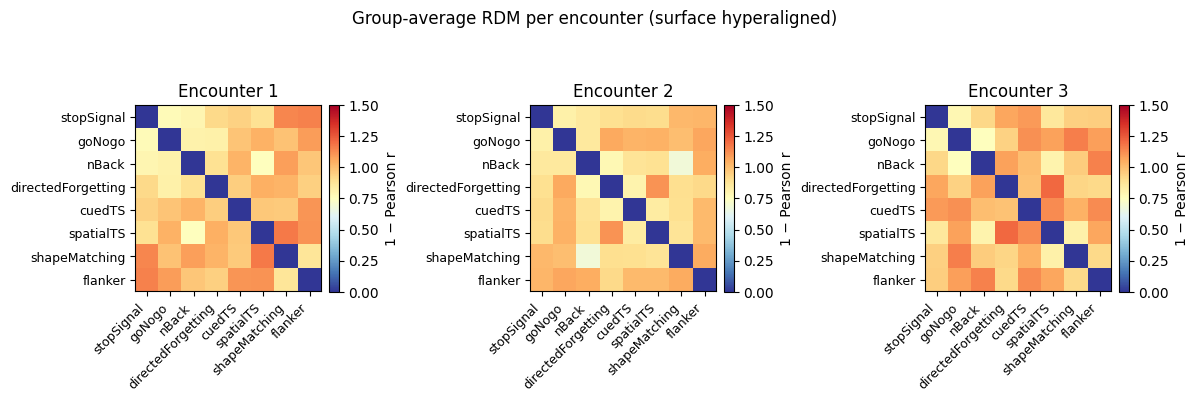

In [5]:
n_enc = len(valid_encs)
fig, axes = plt.subplots(1, n_enc, figsize=(4 * n_enc, 4))
if n_enc == 1:
    axes = [axes]

for ax, enc in zip(axes, valid_encs):
    rdm = group_rdms[enc]
    im  = ax.imshow(rdm, vmin=0, vmax=1.5, cmap='RdYlBu_r')
    ax.set_xticks(range(n_contrasts)); ax.set_yticks(range(n_contrasts))
    ax.set_xticklabels(contrast_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(contrast_labels, fontsize=9)
    ax.set_title(f'Encounter {int(enc)}')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='1 − Pearson r')

plt.suptitle('Group-average RDM per encounter (surface hyperaligned)', y=1.02)
plt.tight_layout()
plt.savefig(RSA_DIR / 'rdm_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hierarchical clustering (dendrogram) per encounter

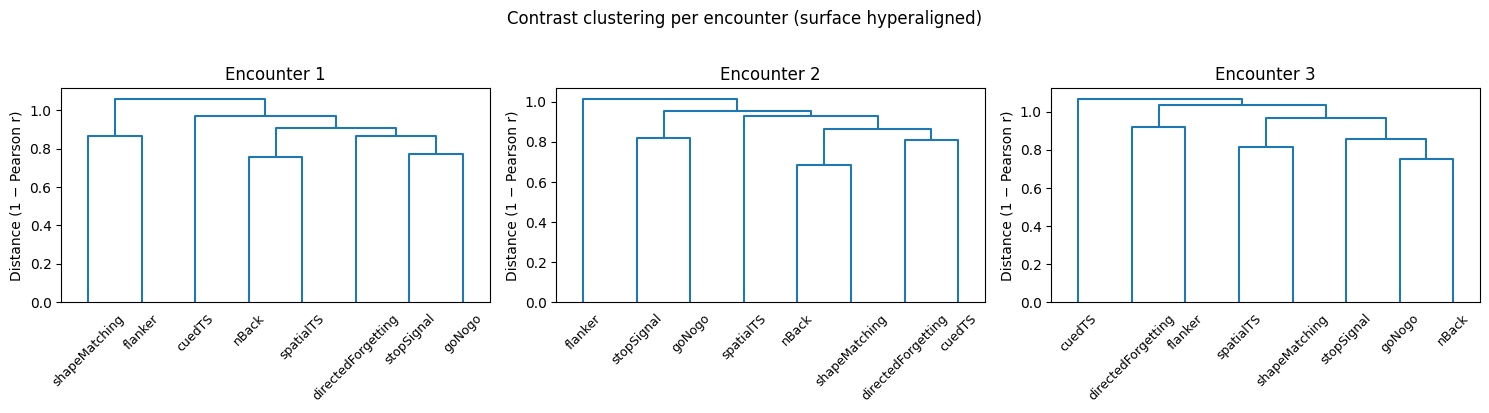

In [6]:
fig, axes = plt.subplots(1, n_enc, figsize=(5 * n_enc, 4))
if n_enc == 1:
    axes = [axes]

for ax, enc in zip(axes, valid_encs):
    rdm = group_rdms[enc]
    condensed = squareform(rdm)
    Z = linkage(condensed, method='average')
    dendrogram(Z, labels=contrast_labels, ax=ax, leaf_rotation=45,
               leaf_font_size=9, color_threshold=0.6 * condensed.max())
    ax.set_title(f'Encounter {int(enc)}')
    ax.set_ylabel('Distance (1 − Pearson r)')

plt.suptitle('Contrast clustering per encounter (surface hyperaligned)', y=1.02)
plt.tight_layout()
plt.savefig(RSA_DIR / 'rdm_dendrograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Second-order RSA: encounter × encounter

Spearman r between off-diagonal RDM elements across pairs of encounters.
High correlation = similar representational geometry at those two time points.

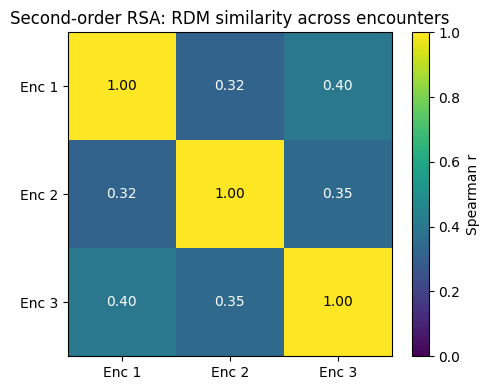

Spearman r matrix:
[[1.    0.32  0.396]
 [0.32  1.    0.346]
 [0.396 0.346 1.   ]]


In [7]:
idx = np.triu_indices(n_contrasts, k=1)
enc_vecs = {enc: group_rdms[enc][idx] for enc in valid_encs}

n_v = len(valid_encs)
second_order_r = np.zeros((n_v, n_v))
second_order_p = np.zeros((n_v, n_v))

for i, e1 in enumerate(valid_encs):
    for j, e2 in enumerate(valid_encs):
        r, p = spearmanr(enc_vecs[e1], enc_vecs[e2])
        second_order_r[i, j] = r
        second_order_p[i, j] = p

enc_tick_labels = [f'Enc {int(e)}' for e in valid_encs]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(second_order_r, vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(range(n_v)); ax.set_yticks(range(n_v))
ax.set_xticklabels(enc_tick_labels)
ax.set_yticklabels(enc_tick_labels)
plt.colorbar(im, ax=ax, label='Spearman r')
for i in range(n_v):
    for j in range(n_v):
        ax.text(j, i, f'{second_order_r[i,j]:.2f}', ha='center', va='center',
                color='white' if second_order_r[i,j] < 0.5 else 'black', fontsize=10)
ax.set_title('Second-order RSA: RDM similarity across encounters')
plt.tight_layout()
plt.savefig(RSA_DIR / 'second_order_rsa.png', dpi=150, bbox_inches='tight')
plt.show()

print('Spearman r matrix:')
print(np.round(second_order_r, 3))

## 6. MDS: representational geometry across encounters

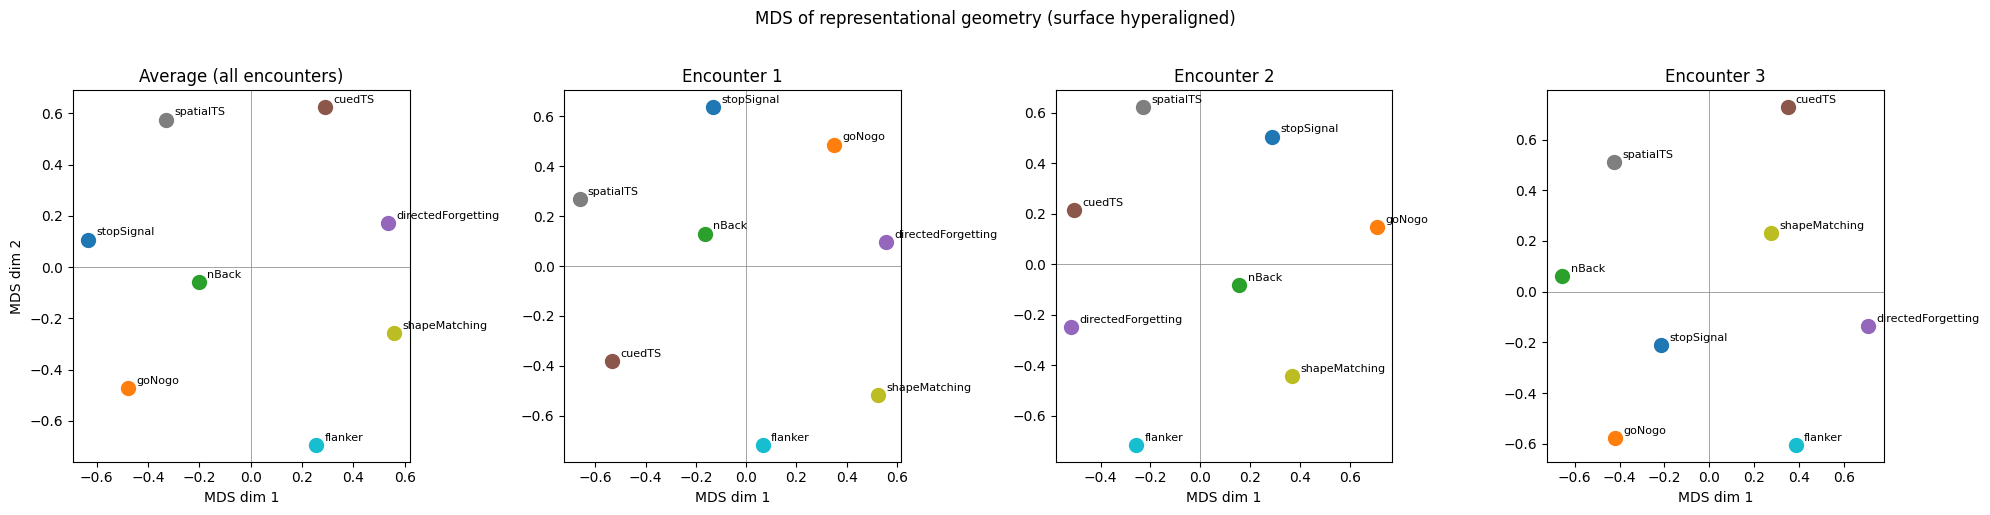

In [8]:
avg_rdm  = np.mean([group_rdms[enc] for enc in valid_encs], axis=0)
mds_ref  = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=10)
ref_coords = mds_ref.fit_transform(avg_rdm)

mds_coords = {}
for enc in valid_encs:
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=10)
    mds_coords[enc] = mds.fit_transform(group_rdms[enc])

task_colors = plt.cm.tab10(np.linspace(0, 1, n_contrasts))

fig, axes = plt.subplots(1, n_enc + 1, figsize=(5 * (n_enc + 1), 5))

ax = axes[0]
for i, label in enumerate(contrast_labels):
    ax.scatter(*ref_coords[i], color=task_colors[i], s=100, zorder=5)
    ax.annotate(label, ref_coords[i], textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_title('Average (all encounters)')
ax.set_xlabel('MDS dim 1'); ax.set_ylabel('MDS dim 2')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

for ax, enc in zip(axes[1:], valid_encs):
    coords = mds_coords[enc]
    for i, label in enumerate(contrast_labels):
        ax.scatter(*coords[i], color=task_colors[i], s=100, zorder=5)
        ax.annotate(label, coords[i], textcoords='offset points', xytext=(6, 3), fontsize=8)
    ax.set_title(f'Encounter {int(enc)}')
    ax.set_xlabel('MDS dim 1')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

plt.suptitle('MDS of representational geometry (surface hyperaligned)', y=1.02)
plt.tight_layout()
plt.savefig(RSA_DIR / 'mds_per_encounter.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-subject RDM variability

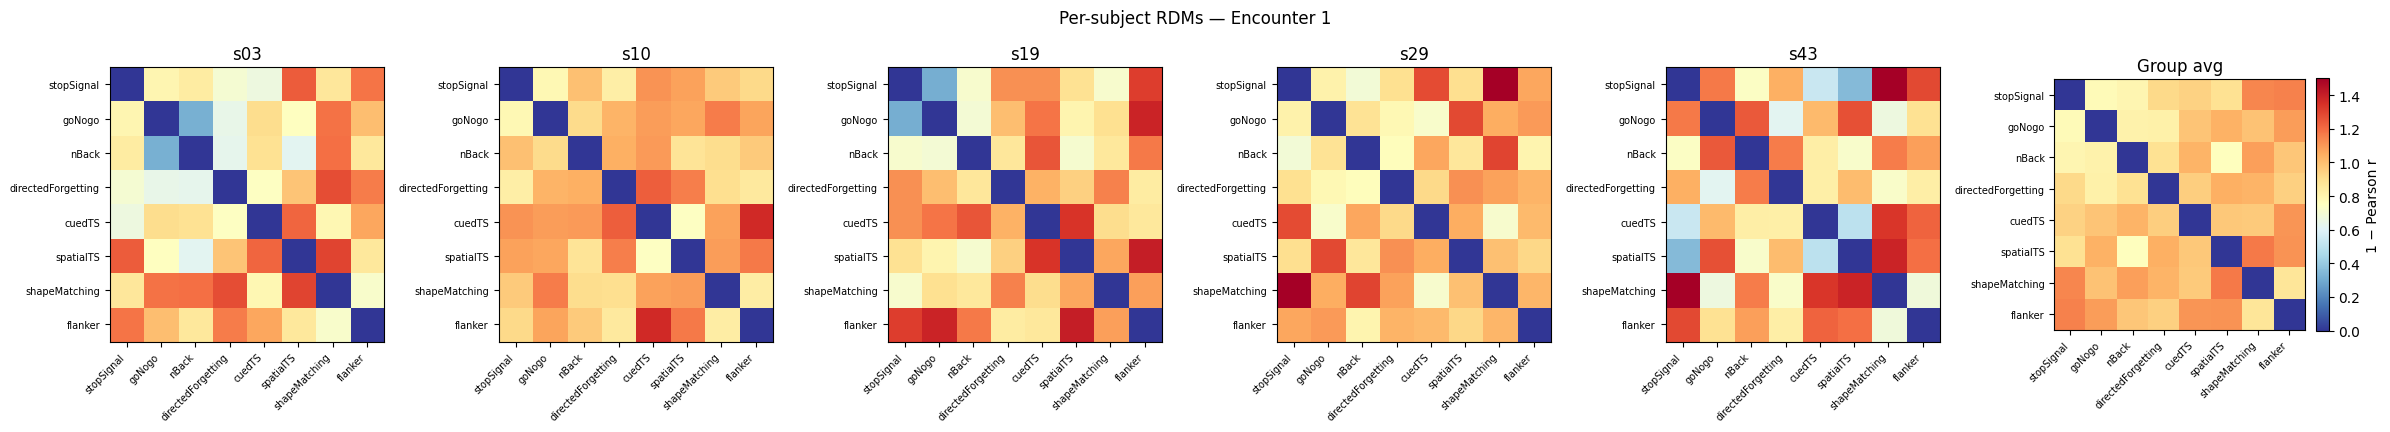

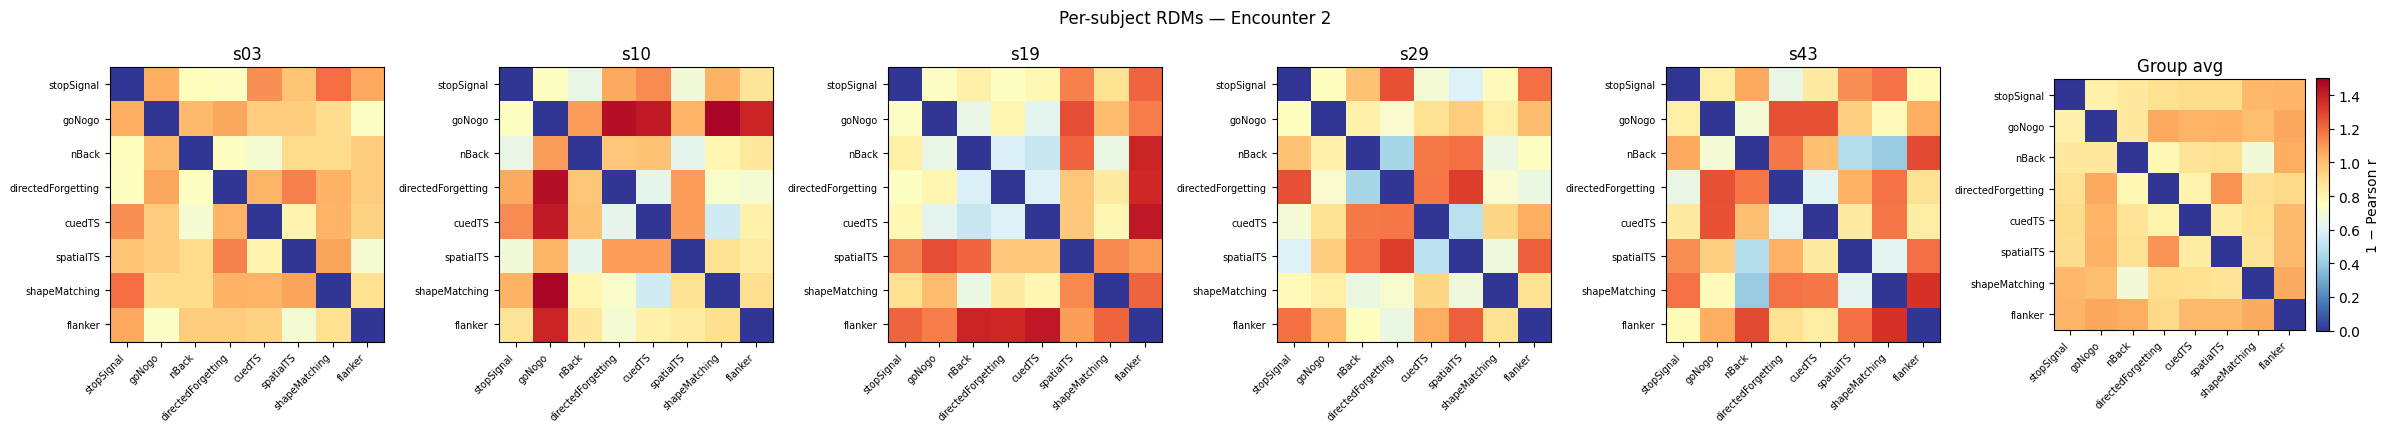

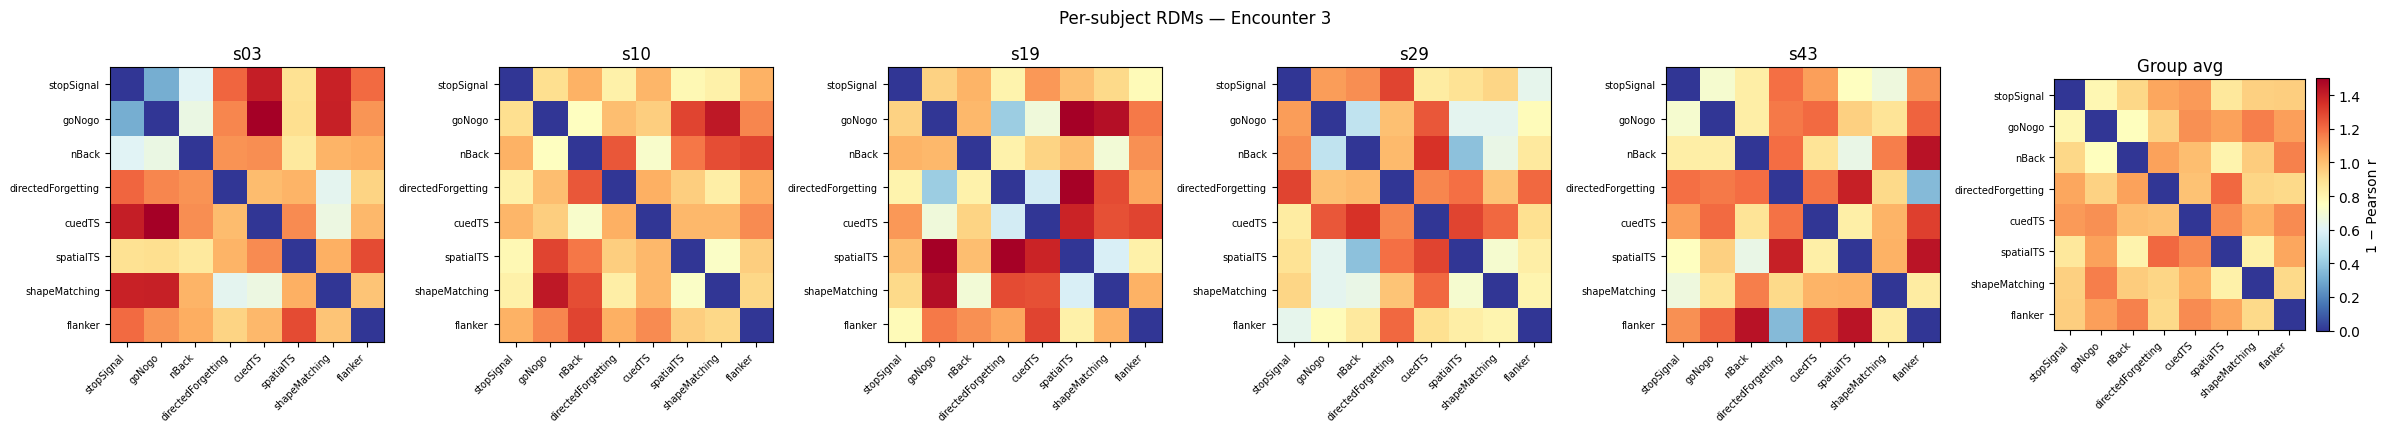

In [9]:
for enc in valid_encs:
    n_subj = len(SUBJECTS)
    fig, axes = plt.subplots(1, n_subj + 1, figsize=(4 * (n_subj + 1), 4))

    for ax, subj, rdm in zip(axes, SUBJECTS, subj_rdms[enc]):
        im = ax.imshow(rdm, vmin=0, vmax=1.5, cmap='RdYlBu_r')
        ax.set_xticks(range(n_contrasts)); ax.set_yticks(range(n_contrasts))
        ax.set_xticklabels(contrast_labels, rotation=45, ha='right', fontsize=7)
        ax.set_yticklabels(contrast_labels, fontsize=7)
        ax.set_title(subj[-3:])

    ax = axes[-1]
    im = ax.imshow(group_rdms[enc], vmin=0, vmax=1.5, cmap='RdYlBu_r')
    ax.set_xticks(range(n_contrasts)); ax.set_yticks(range(n_contrasts))
    ax.set_xticklabels(contrast_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(contrast_labels, fontsize=7)
    ax.set_title('Group avg')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='1 − Pearson r')

    plt.suptitle(f'Per-subject RDMs — Encounter {int(enc)}', y=1.02)
    plt.tight_layout()
    plt.savefig(RSA_DIR / f'rdm_per_subject_enc{enc}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Distance between specific contrast pairs across encounters

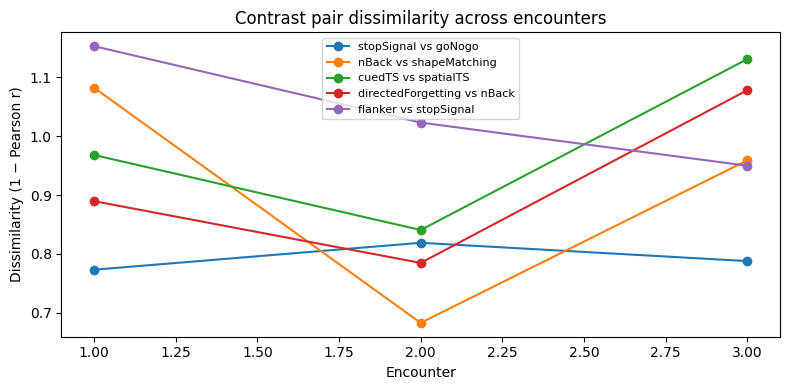

In [10]:
pairs_of_interest = [
    ('stopSignal',  'goNogo'),            # both response inhibition
    ('nBack',       'shapeMatching'),     # working memory / matching
    ('cuedTS',      'spatialTS'),         # task-switching variants
    ('directedForgetting', 'nBack'),      # cognitive control over memory
    ('flanker',     'stopSignal'),        # conflict / inhibition
]

fig, ax = plt.subplots(figsize=(8, 4))
for task_a, task_b in pairs_of_interest:
    idx_a = contrast_labels.index(task_a)
    idx_b = contrast_labels.index(task_b)
    dists = [group_rdms[enc][idx_a, idx_b] for enc in valid_encs]
    ax.plot([int(e) for e in valid_encs], dists, marker='o',
            label=f'{task_a} vs {task_b}')

ax.set_xlabel('Encounter')
ax.set_ylabel('Dissimilarity (1 − Pearson r)')
ax.set_title('Contrast pair dissimilarity across encounters')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RSA_DIR / 'contrast_pair_distances.png', dpi=150, bbox_inches='tight')
plt.show()